### <font color="skyblue"> Preliminaries：隨機變數的分配與抽樣</font>

- 認識機率分配的"樣子"：shape of probability distribution
- 認識隨機樣本的"樣子"：shape of random sample
- 認識抽樣分配的"樣子"：shape of sampling distribution

<hr>

<font color="yellow">機率分配 Probability Distribution</font>
- 繪製下列連續型分配的 PDF 函數：Normal、T、Chi-square、Beta、Gamma、F。
    - 利用改變分配函數的參數，觀察其分配函數的「樣貌」；畫出所有可能的「形狀」並說明（或標示）與參數間的關係。
    - 可以將不同參數的 PDF 函數畫在同一張圖，或選擇切割畫面（subplot）以應付不同參數的表現。
- 繪製離散型分配的 PMF 函數：Binomial、Poisson。
- 近似的分配：
    - 繪製 $Bino(n=100, p=0.1)$ 與 $Norm(\mu=10, \sigma = 3)$ 在同一張圖。注意選取適當的 X 軸範圍。
    - 繪製 $\chi^2(\nu=1000)$ 與 $Norm(\mu=1000, \sigma = 45)$ 在同一張圖。注意選取適當的 X 軸範圍。

<hr>

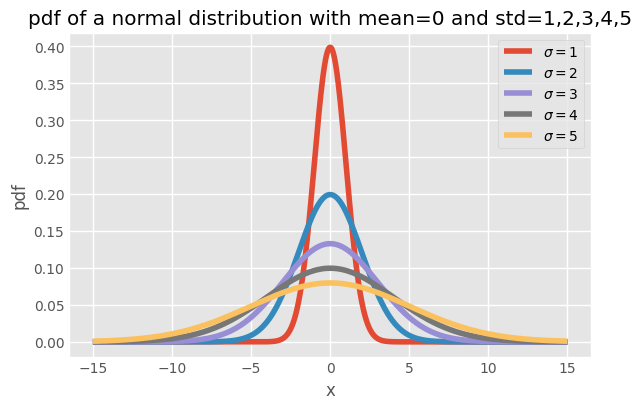

In [13]:
# draw the pdf of a normal distribution with mean=0 and std=1
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# draw the pdf with mean=0 and std=1,2,3,4,5
mu = 0
s = range(1, 6)
x = np.linspace(-15, 15, 1000)
# use broadcasting to compute the pdf for each std
Y = norm.pdf(x[:, np.newaxis], mu, s)
# draw the pdf from Y
fig, ax = plt.subplots(figsize=(6, 4))
# do not use a for loop to draw the pdf, instead use the following code
# add labels to the legend for each std
ax.plot(x, Y, label=[f'$\sigma={i}$' for i in s])
# for i in range(5):
#     plt.plot(x, Y[:, i], label=f'$\sigma={s[i]}$')

# for std in range(1, 6):
#     y = norm.pdf(x, 0, std)
#     plt.plot(x, y, label=f'$\sigma={std}$')
ax.legend()    
ax.set_xlabel('x')
ax.set_ylabel('pdf')
ax.set_title('pdf of a normal distribution with mean=0 and std=1,2,3,4,5')
plt.show()

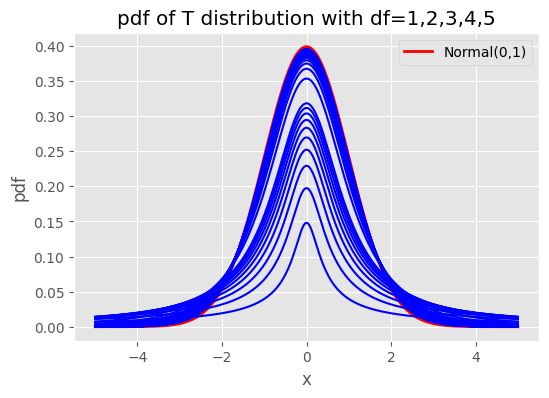

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# draw the pdf of t distribution with df=1,2,3,4,5
# df = range(1, 6)
# set df from [0.1:0.1:0.9] and [1:30]
df = np.concatenate([np.arange(0.1, 1.0, 0.1), np.arange(1, 31)])
x = np.linspace(-5, 5, 1000)
Y = t.pdf(x[:, np.newaxis], df)
# use ggplot style
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 4))
# draw a standard normal distribution for comparison
ax.plot(x, norm.pdf(x), color='r', linewidth=2, label='Normal(0,1)')

ax.plot(x, Y, color='b')
ax.legend()    
ax.set_xlabel('x')
ax.set_ylabel('pdf')
ax.set_title('pdf of T distribution with df=1,2,3,4,5')
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import t, norm
from IPython.display import HTML

# reuse the same df grid and x-axis as the previous cell
# df = np.concatenate([np.arange(0.1, 1.0, 0.1), np.arange(1, 31)])
x = np.linspace(-5, 5, 1000)

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 4))

# static reference curve: standard normal
ax.plot(x, norm.pdf(x), color='r', linewidth=2, label='Normal(0,1)')

ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 0.6)
ax.set_xlabel('x')
ax.set_ylabel('pdf')
title = ax.set_title('')

# one persistent line per df value, added progressively and never erased
lines = [ax.plot([], [], color='b', linewidth=1, alpha=0.4)[0] for _ in df]
lines[0].set_label('T(df)')
ax.legend()

def init():
    for line in lines:
        line.set_data([], [])
    title.set_text('')
    return lines + [title]

def update(frame):
    d = df[frame]
    lines[frame].set_data(x, t.pdf(x, d))
    title.set_text(f'pdf of T distribution with df={d:.1f}')
    return lines + [title]

anim = FuncAnimation(fig, update, frames=len(df), init_func=init, blit=True, interval=150)
plt.close(fig)
HTML(anim.to_jshtml())


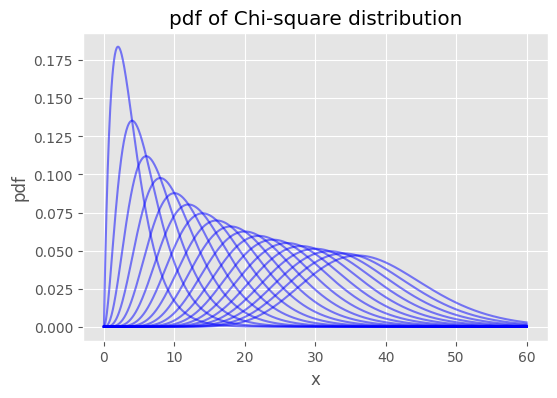

In [21]:
# draw the pdf of chi-square distribution with df=1,2,3,4,5
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

df = range(4, 40, 2)
x = np.linspace(0, 60, 1000)
Y = chi2.pdf(x[:, np.newaxis], df)
# use ggplot style
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 4))
# ax.set_xlim(0, 30)
ax.plot(x, Y, color='b', alpha=0.5)
# ax.legend()    
ax.set_xlabel('x')
ax.set_ylabel('pdf')
ax.set_title('pdf of Chi-square distribution')
plt.show()

<font color="yellow">隨機樣本</font>：從前述的每個分配中（各挑一組參數）產生 N 個隨機樣本
- 繪製直方圖（Histogram）、盒鬚圖（Boxplot）、常態機率圖（Normal Probability plot）、經驗累積機率函數（Empirical CDF）。將四張圖繪製在 2x2 的子圖上。
- 選擇不同大小的樣本數 $N$ 以展現樣本數對圖形產生的影響。

<hr>

<font color="yellow">抽樣分配 Sampling Distribution</font> 

利用隨機樣本並繪製直方圖（含真實 PDF 圖）與 ECDF 圖（含真實 CDF 圖）來證實（非證明）

1. $Y = X^2 $，其中 $X \sim N(0, 1)$，則 $Y \sim \chi^2(1)$。
1. $Y = X_1 + X_2$, 其中 $X_1 \sim \chi^2(2), X_2 \sim \chi^2(4)$，則 $Y \sim \chi^2(6)$。
1. $Y = \frac{X_1/d_1}{X_2/d_2}$, 其中 $X_1 \sim \chi^2(d_1)$ and $X_2 \sim \chi^2(d_2)$，則 $Y \sim F(d_1, d_2)$。

注意：樣本數的大小是驗證的關鍵，愈大愈好。實驗時分別選擇樣本數 n=30, 100, 500, 1000，並觀察樣本數多寡的影響。
